# Catalog set algebra: `query` / `intersect` / `union`

Catalogs support set-algebra operations that return new catalogs —
composable filters and joins over file collections. This notebook
shows the three patterns:

- `query` filters by space + time.
- `intersect` pairs two catalogs by spatial + temporal overlap.
- `union` concatenates two catalogs (with auto-reproject).

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import shapely.geometry

import geotoolz as gz

## Two synthetic catalogs

`imagery` — three Sentinel-2 footprints, one per day.
`labels` — one vector dataset covering a slightly different area.

In [2]:
def make_catalog(rows: list[dict], crs: str = "EPSG:32629", backend: str = "raster"):
    gdf = gpd.GeoDataFrame(rows, geometry="geometry", crs=crs)
    return gz.InMemoryGeoCatalog(gdf, backend=backend)


imagery = make_catalog(
    [
        {
            "filepath": f"S2_{day}.tif",
            "geometry": shapely.geometry.box(
                500_000 + i * 1000, 4_000_000, 500_000 + (i + 1) * 1000, 4_001_000
            ),
            "start_time": pd.Timestamp(f"2024-06-{day}"),
            "end_time": pd.Timestamp(f"2024-06-{day} 23:59:59.999999"),
        }
        for i, day in enumerate(["01", "02", "03"])
    ]
)
print(f"len(imagery): {len(imagery)}")
print(f"imagery.total_bounds: {imagery.total_bounds}")

labels = make_catalog(
    [
        {
            "filepath": "labels.gpkg",
            "geometry": shapely.geometry.box(500_500, 4_000_000, 502_500, 4_001_000),
            "start_time": pd.Timestamp("2024-06-01"),
            "end_time": pd.Timestamp("2024-06-30"),
        }
    ],
    backend="vector",
)
print(f"len(labels): {len(labels)}")
print(f"labels.total_bounds: {labels.total_bounds}")

len(imagery): 3
imagery.total_bounds: (500000.0, 4000000.0, 503000.0, 4001000.0)
len(labels): 1
labels.total_bounds: (500500.0, 4000000.0, 502500.0, 4001000.0)


Plot the footprints to make the spatial layout explicit.

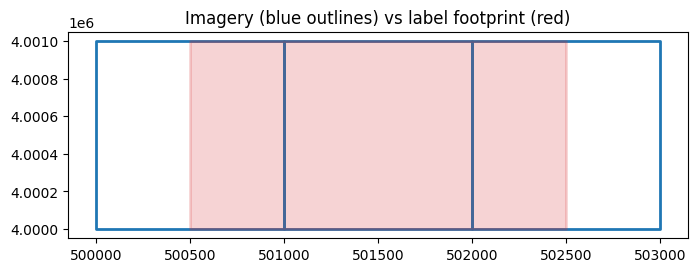

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.5))
imagery.gdf.plot(ax=ax, edgecolor="C0", facecolor="none", linewidth=2, label="imagery")
labels.gdf.plot(
    ax=ax, edgecolor="C3", facecolor="C3", alpha=0.2, linewidth=2, label="labels"
)
ax.set_aspect("equal")
ax.set_title("Imagery (blue outlines) vs label footprint (red)")
plt.show()

## `query` — spatial AND temporal filter

Ask for files overlapping the **middle** column of the AOI, between
Jun 1 and Jun 2 — expected two hits (rows 0 and 1).

In [4]:
hits = imagery.query(
    bounds=(500_500, 4_000_000, 501_500, 4_001_000),
    crs="EPSG:32629",
    time=("2024-06-01", "2024-06-02"),
)
print(f"len(hits): {len(hits)}   # rows 0 and 1")
print(hits.gdf[["filepath"]])

len(hits): 2   # rows 0 and 1
                                                    filepath
datetime                                                    
[2024-06-01 00:00:00, 2024-06-01 23:59:59.999999]  S2_01.tif
[2024-06-02 00:00:00, 2024-06-02 23:59:59.999999]  S2_02.tif


## `intersect` — cross-catalog AND

`intersect(imagery, labels)` returns the rows whose **footprints AND
time intervals** overlap. Each surviving row's geometry is clipped to
the intersection, and the time interval is the per-row temporal
intersection.

In [5]:
paired = gz.intersect(imagery, labels)
print(
    f"len(paired): {len(paired)}    # 2 of 3 imagery rows overlap the labels footprint"
)
print(paired.gdf[["geometry"]].to_string())

len(paired): 3    # 2 of 3 imagery rows overlap the labels footprint
                                                                                                                                     geometry
datetime                                                                                                                                     
[2024-06-01 00:00:00, 2024-06-01 23:59:59.999999]  POLYGON ((501000 4000000, 500500 4000000, 500500 4001000, 501000 4001000, 501000 4000000))
[2024-06-02 00:00:00, 2024-06-02 23:59:59.999999]  POLYGON ((502000 4000000, 501000 4000000, 501000 4001000, 502000 4001000, 502000 4000000))
[2024-06-03 00:00:00, 2024-06-03 23:59:59.999999]  POLYGON ((502500 4001000, 502500 4000000, 502000 4000000, 502000 4001000, 502500 4001000))


`spatial_only=True` ignores time — the right tool for pairing imagery
with static labels (DEMs, land-cover maps).

In [6]:
paired_static = gz.intersect(imagery, labels, spatial_only=True)
print(f"len(paired_static): {len(paired_static)}   # same 2 rows; time ignored")

len(paired_static): 3   # same 2 rows; time ignored


Visualise: clipped footprints from `intersect`.

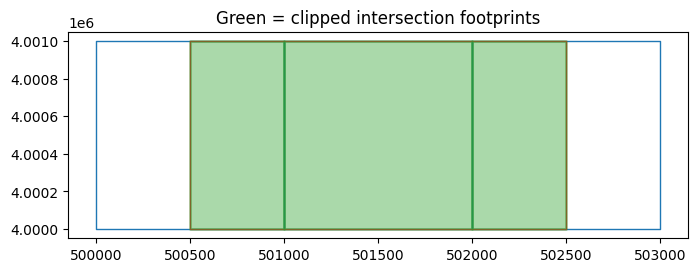

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.5))
imagery.gdf.plot(ax=ax, edgecolor="C0", facecolor="none", linewidth=1, label="imagery")
labels.gdf.plot(ax=ax, edgecolor="C3", facecolor="none", linewidth=1, label="labels")
paired.gdf.plot(ax=ax, edgecolor="C2", facecolor="C2", alpha=0.4, linewidth=2)
ax.set_aspect("equal")
ax.set_title("Green = clipped intersection footprints")
plt.show()

## `union` — cross-catalog OR

Useful when you have multiple sensors (Landsat 7 + Landsat 8, or S2 +
S3) you want to treat as a single virtual dataset.

In [8]:
sensor_b = make_catalog(
    [
        {
            "filepath": "L8_2024-06-01.tif",
            "geometry": shapely.geometry.box(503_000, 4_000_000, 504_000, 4_001_000),
            "start_time": pd.Timestamp("2024-06-01"),
            "end_time": pd.Timestamp("2024-06-01 23:59:59.999999"),
        }
    ]
)
combined = gz.union(imagery, sensor_b)
print(f"len(combined): {len(combined)}   # 3 + 1 = 4 rows")
print(combined.gdf[["filepath"]].to_string())

len(combined): 4   # 3 + 1 = 4 rows
                                                            filepath
datetime                                                            
[2024-06-01 00:00:00, 2024-06-01 23:59:59.999999]          S2_01.tif
[2024-06-02 00:00:00, 2024-06-02 23:59:59.999999]          S2_02.tif
[2024-06-03 00:00:00, 2024-06-03 23:59:59.999999]          S2_03.tif
[2024-06-01 00:00:00, 2024-06-01 23:59:59.999999]  L8_2024-06-01.tif


`union` silently reprojects the second catalog if its CRS doesn't
match — `self.crs` always wins.

In [9]:
sensor_b_4326 = make_catalog(
    [
        {
            "filepath": "L8_4326.tif",
            "geometry": shapely.geometry.box(-13.0, 35.0, -12.9, 35.1),
            "start_time": pd.Timestamp("2024-06-01"),
            "end_time": pd.Timestamp("2024-06-01 23:59:59.999999"),
        }
    ],
    crs="EPSG:4326",
)
reprojected = gz.union(imagery, sensor_b_4326)
print(f"len(reprojected): {len(reprojected)}")
print(f"reprojected.gdf.crs: {reprojected.gdf.crs}")
print("→ second catalog's footprints were reprojected into UTM 29N silently")

len(reprojected): 4
reprojected.gdf.crs: EPSG:32629
→ second catalog's footprints were reprojected into UTM 29N silently


## `where` — pandas-`.query()` passthrough

Sometimes you want a non-geometric filter (cloud %, sensor, mission).
`where` exposes that escape hatch.

In [10]:
imagery.gdf["mission"] = ["S2A", "S2B", "S2A"]
imagery_a = imagery.where("mission == 'S2A'")
print(f"len(imagery_a): {len(imagery_a)}   # 2 rows tagged S2A")

len(imagery_a): 2   # 2 rows tagged S2A
